In [18]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [19]:
df = pd.read_csv('/bettik/PROJECTS/pr-regional-climate/bricej/paper/t2m_era5_Jan_trends_HIMAPgrouped_regions_2000-2019.csv')

In [20]:
df

,region,slope,intercept,rvalue,pvalue,stderr
0,Tien Shan,-0.021017,301.063312,-0.063268,0.791019,0.078141
1,Pamir Alay,0.032050,197.985593,0.090644,0.703905,0.082997
2,Pamir,0.052022,149.620596,0.186698,0.430613,0.064522
3,Hindu Kush,0.049693,162.385596,0.186594,0.430874,0.061669
4,Karakoram,0.031082,186.440381,0.139934,0.556253,0.051839
5,Kunlun,0.032026,191.230164,0.130084,0.584636,0.057536
6,Spiti Lahaul,-0.002894,267.877467,-0.015168,0.949392,0.044959
7,Central Himalaya,-0.019808,309.730475,-0.084027,0.724681,0.055367
8,Bhutan,-0.017877,306.520899,-0.084240,0.724010,0.049840
9,Nyainqentangla,-0.017338,296.090233,-0.068311,0.774756,0.059683


In [21]:
iyear = 2000
fyear = 2019

In [22]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
path = '/bettik/PROJECTS/pr-regional-climate/bricej/paper/'
var = 't2m'

var_trends = {}
for month in months :
    monthly_trends = pd.read_csv(f'{path}{var}_era5_{month}_trends_HIMAPgrouped_regions_{iyear}-{fyear}.csv')
    var_trends[month] = monthly_trends

In [23]:
var_trends

{'Jan':               region     slope   intercept    rvalue    pvalue    stderr
 0          Tien Shan -0.021017  301.063312 -0.063268  0.791019  0.078141
 1         Pamir Alay  0.032050  197.985593  0.090644  0.703905  0.082997
 2              Pamir  0.052022  149.620596  0.186698  0.430613  0.064522
 3         Hindu Kush  0.049693  162.385596  0.186594  0.430874  0.061669
 4          Karakoram  0.031082  186.440381  0.139934  0.556253  0.051839
 5             Kunlun  0.032026  191.230164  0.130084  0.584636  0.057536
 6       Spiti Lahaul -0.002894  267.877467 -0.015168  0.949392  0.044959
 7   Central Himalaya -0.019808  309.730475 -0.084027  0.724681  0.055367
 8             Bhutan -0.017877  306.520899 -0.084240  0.724010  0.049840
 9     Nyainqentangla -0.017338  296.090233 -0.068311  0.774756  0.059683
 10          Inner TP -0.007017  273.349680 -0.033531  0.888394  0.049295,
 'Feb':               region     slope   intercept    rvalue    pvalue    stderr
 0          Tien Shan -

In [28]:
domains = ["Tien Shan", "Pamir Alay", "Pamir", "Hindu Kush", "Karakoram", "Kunlun", "Spiti Lahaul", "Central Himalaya",
           "Bhutan", "Nyainqentangla", "Inner TP"]

# valeur de la pente
var_slopes = {}
for dom in domains:
    var_slopes[dom] = {}
    for month in months:
        var_slopes[dom][month] = var_trends[month].loc[var_trends[month]['region'] == dom, 'slope'].values[0] * 10 # *10 -> per decade

# valeur de la pvalue
var_pvalue = {}
for dom in domains:
    var_pvalue[dom] = {}
    for month in months:
        var_pvalue[dom][month] = var_trends[month].loc[var_trends[month]['region'] == dom, 'pvalue'].values[0]

In [29]:
var_slopes

{'Tien Shan': {'Jan': np.float64(-0.210168479976797),
  'Feb': np.float64(-0.34093205731614096),
  'Mar': np.float64(0.657416092722039),
  'Apr': np.float64(0.75142468904194),
  'May': np.float64(-0.172896076862077),
  'Jun': np.float64(-0.124113613501527),
  'Jul': np.float64(0.8138634244302161),
  'Aug': np.float64(0.218645138848096),
  'Sep': np.float64(0.308662586642387),
  'Oct': np.float64(0.276889887071193),
  'Nov': np.float64(-0.866486284069548),
  'Dec': np.float64(0.35377376240895203)},
 'Pamir Alay': {'Jan': np.float64(0.32049973566729295),
  'Feb': np.float64(0.158675344366776),
  'Mar': np.float64(0.65764141799812),
  'Apr': np.float64(0.27828061670289),
  'May': np.float64(0.330073765345982),
  'Jun': np.float64(-0.10924008018092099),
  'Jul': np.float64(1.131328152534657),
  'Aug': np.float64(0.291886408526198),
  'Sep': np.float64(0.73063304011983),
  'Oct': np.float64(0.21704216290237302),
  'Nov': np.float64(-0.207511500308388),
  'Dec': np.float64(0.4752869570165640

In [30]:
var_pvalue

{'Tien Shan': {'Jan': np.float64(0.7910187582278503),
  'Feb': np.float64(0.6486699670845479),
  'Mar': np.float64(0.395428077319117),
  'Apr': np.float64(0.1646646848606243),
  'May': np.float64(0.6914044142787081),
  'Jun': np.float64(0.6515629946051947),
  'Jul': np.float64(0.0094081281118359),
  'Aug': np.float64(0.4029118161460084),
  'Sep': np.float64(0.3752908348176274),
  'Oct': np.float64(0.6392556219729901),
  'Nov': np.float64(0.1340750612161723),
  'Dec': np.float64(0.4917846830693722)},
 'Pamir Alay': {'Jan': np.float64(0.703905374936926),
  'Feb': np.float64(0.8514748120343458),
  'Mar': np.float64(0.3550210215140023),
  'Apr': np.float64(0.4991774561236994),
  'May': np.float64(0.5487546328973287),
  'Jun': np.float64(0.8007301379339883),
  'Jul': np.float64(0.0004582711653375),
  'Aug': np.float64(0.2540195251908125),
  'Sep': np.float64(0.0489800458235347),
  'Oct': np.float64(0.6845293830845454),
  'Nov': np.float64(0.7238890895812804),
  'Dec': np.float64(0.375853852

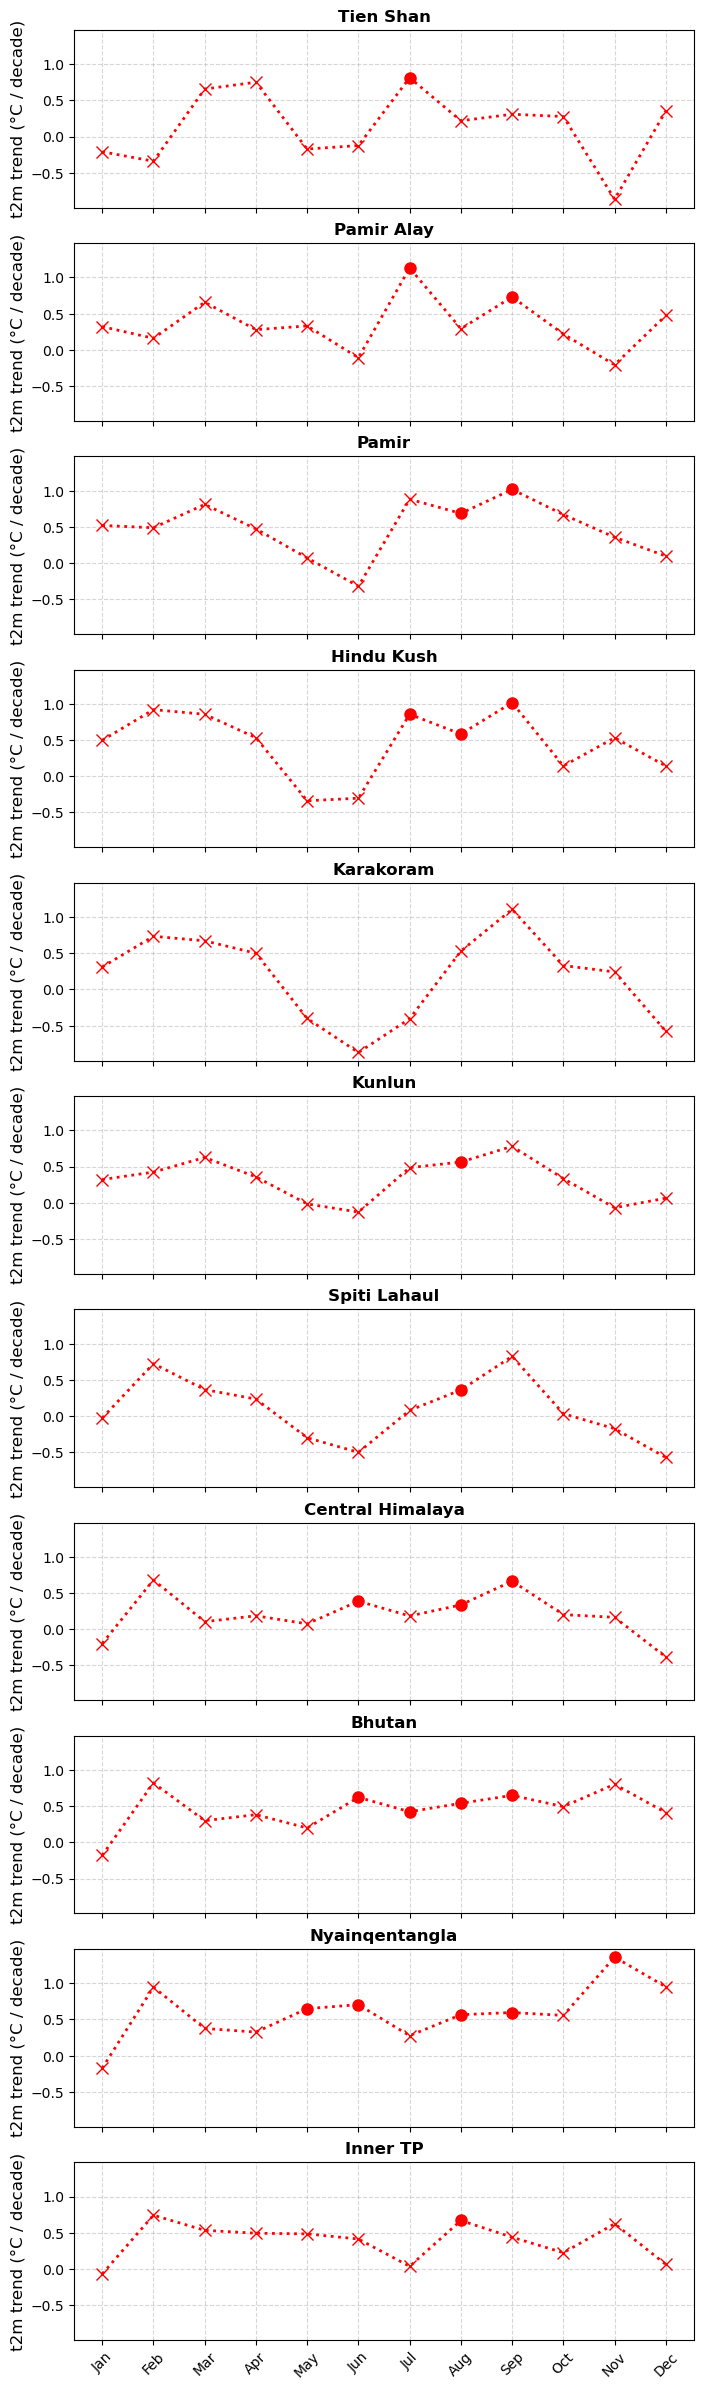

In [39]:
fig, axes = plt.subplots(11, 1, figsize=(8, 30), sharey=True)
axes = axes.flatten()

for i, dom in enumerate(domains):
    ax = axes[i]

    slopes = [var_slopes[dom][m] for m in months]
    pvalues = [var_pvalue[dom][m] for m in months]

    markers = ['x' if p > 0.05 else 'o' for p in pvalues]

    # ligne pointillée pour relier les trends
    ax.plot(
        range(1, 13),
        slopes,
        linestyle=':',
        linewidth=2,
        color='red'
    )

    # points mois par mois, marker en fonction de la pvalue
    for m_idx, month_num in enumerate(range(1, 13)): # m_idx de 0 à 11 et month_num de 1 à 12
        ax.plot(
            month_num,
            slopes[m_idx],
            marker=markers[m_idx],
            linestyle='None',
            markersize=8,
            color='red'
        )

    ax.set_title(dom, fontsize=12, weight="bold")
    ax.set_xticks(range(1, 13))

    ax.set_ylabel('t2m trend (°C / decade)', fontsize=12)
    if i in [10]:
        ax.set_xticklabels(months, rotation=45, fontsize=10)
    if i in [0,1,2,3,4,5,6,7,8,9]:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5)
    
plt.show()